# BLOCK 1 · SETUP, CONFIGURATION & UTILITIES

In [1]:
!pip install transformers accelerate bitsandbytes scipy jiwer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.1 MB/s eta 0:00:00


In [2]:
"""
============================================================================
ICCIT · Brain-to-Text '25 — Hybrid acoustic model + KenLM + Qwen2.5-7B rescoring
============================================================================
Single-file, error-free reimplementation of the original notebook.

WHAT IS DIFFERENT FROM THE NOTEBOOK (by request):
  * TRAINING CODE IS PRESENT BUT SKIPPED. `SKIP_TRAINING = True`, so the model
    + training functions are all defined and ready, but no epochs run. Flip it
    to False (and provide the data) to actually train from scratch.
  * BEST HYPERPARAMETERS ARE PINNED AS DEFAULTS. The expensive lm_weight/lambda
    sweeps are OFF (`RUN_HYPERPARAM_SWEEPS = False`); instead the single best
    combo found by the notebook's own sweep is hard-set:
        lm_weight        = 4.5
        LLM_FUSION_WEIGHT = 0.75   (fusion lambda)
        rescoring LLM     = Qwen/Qwen2.5-7B (4-bit nf4)
        beam=250, nbest=30, gate percentiles 1 / 75, margin-adaptive fusion
    -> validation WER 7.62% / CER 5.31% / PER 12.12%.
  * Only the numeric pipeline (metrics + submission) is kept; the many
    near-identical paper-plot cells are dropped to stay compact and runnable.

REQUIREMENTS (Kaggle, internet ON for the LLM + flashlight-text):
    pip install transformers accelerate bitsandbytes scipy jiwer editdistance
    pip install h5py torchaudio flashlight-text
============================================================================
"""

# ============================================================================
# BLOCK 1 · SETUP, CONFIGURATION & UTILITIES
# ============================================================================
import os
import gc
import re
import sys
import json
import random
import subprocess
import importlib
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
from tqdm import tqdm
import editdistance
import jiwer
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

try:
    import kagglehub
except ImportError:
    kagglehub = None


# --- AMP compatibility shim (avoids the deprecated torch.cuda.amp API) ------
try:
    from torch.amp import autocast as _amp_autocast, GradScaler as _AmpGradScaler

    def amp_autocast(enabled=True):
        return _amp_autocast('cuda', enabled=enabled)

    def make_grad_scaler(enabled=True):
        return _AmpGradScaler('cuda', enabled=enabled)
except Exception:  # older torch
    from torch.cuda.amp import autocast as _cuda_autocast, GradScaler as _CudaGradScaler

    def amp_autocast(enabled=True):
        return _cuda_autocast(enabled=enabled)

    def make_grad_scaler(enabled=True):
        return _CudaGradScaler(enabled=enabled)


def resolve_competition_path(local_path, competition_slug):
    """Use the local Kaggle mount if present, otherwise fetch via kagglehub."""
    if os.path.exists(local_path):
        return local_path
    if kagglehub is not None:
        return os.path.join(kagglehub.competition_download(competition_slug),
                            "t15_copyTask_neuralData/hdf5_data_final")
    raise FileNotFoundError(f"{local_path} not found and kagglehub unavailable.")


# 40-way phoneme inventory (index 0 = CTC blank, last entry = word boundary).
# These IDs are exactly what's stored in each trial's `seq_class_ids`.
PHONEME_VOCAB = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B', 'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G', 'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M', 'N',
    'NG', 'OW', 'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW', 'V', 'W',
    'Y', 'Z', 'ZH', ' | ',
]

CONFIG = {
    'data_dir': resolve_competition_path(
        '/kaggle/input/competitions/brain-to-text-25/t15_copyTask_neuralData/hdf5_data_final',
        'brain-to-text-25',
    ),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'batch_size': 16,
    'num_epochs': 82,

    # --- Model architecture (BEST) ---
    'd_model': 384,
    'n_heads': 6,
    'n_layers': 4,
    'd_ff': 1536,
    'patch_size': 3,
    'lstm_hidden': 256,
    'lstm_layers': 2,
    'n_classes': len(PHONEME_VOCAB),   # 40

    # --- Regularization & adaptation (BEST) ---
    'dropout': 0.4,
    'head_dim': 256,
    'attn_dropout': 0.5,
    'drop_path_rate': 0.2,
    'smooth_kernel_std': 2.0,
    'smooth_kernel_size': 100,
    'drift_lambda': 0.01,

    # --- Optimizer (BEST) ---
    'learning_rate': 5e-4,
    'weight_decay': 1e-4,
    'use_augmentation': True,

    # --- Memory / stability ---
    'use_amp': True,
    'grad_clip': 5.0,

    # --- Checkpointing ---
    'resume_from_checkpoint': None,
    'checkpoint_dir': '/kaggle/working',

    # --- LLM rescoring gate (BEST) ---
    'llm_gate_percentile': 1,          # skip only the most clearly incoherent trials
    'llm_gate_margin_percentile': 75,  # let the LLM rescore more "confident" cases too
    'llm_fusion_weight': 0.75,          # BEST fusion lambda (pinned)
}

# --- Skip switches ----------------------------------------------------------
# Training is DEFINED below but not RUN. Set False to train from scratch.
SKIP_TRAINING = True
PRETRAINED_CKPT_DATASET = 'shohan3125/brain-to-text-checkpoint'

# The per-run lm_weight/lambda grid search (BLOCK 5.6) is controlled by this
# single flag - set it here, nowhere else. True = actually run the sweep;
# False = skip BLOCK 5.6 and use the pinned defaults above.
RUN_HYPERPARAM_SWEEPS = True

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
figures_dir = os.path.join(CONFIG['checkpoint_dir'], 'figures')
os.makedirs(figures_dir, exist_ok=True)

print(f"Device: {CONFIG['device']}")
print(f"PyTorch version: {torch.__version__}")
print(f"SKIP_TRAINING: {SKIP_TRAINING} | RUN_HYPERPARAM_SWEEPS: {RUN_HYPERPARAM_SWEEPS}")
print(f"Phoneme classes (incl. blank): {CONFIG['n_classes']}")


# --- Helper: Stochastic Depth ----------------------------------------------
def drop_path(x, drop_prob: float = 0., training: bool = False, scale_by_keep: bool = True):
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
    if keep_prob > 0.0 and scale_by_keep:
        random_tensor.div_(keep_prob)
    return x * random_tensor


# --- Helper: Global Session Mapper -----------------------------------------
def get_session2idx(data_dir):
    """Scans data directory to find all unique sessions chronologically."""
    paths = glob(f'{data_dir}/**/data_*.hdf5', recursive=True)
    sessions = sorted(list(set([Path(p).parent.name for p in paths])))
    return {s: i for i, s in enumerate(sessions)}


# --- Helper: Kaggle dataset resolver ---------------------------------------
def resolve_kaggle_dataset(slug, local_dirname=None):
    """Prefer an already-attached dataset under /kaggle/input, fall back to
    kagglehub.dataset_download() only if nothing is found locally."""
    if local_dirname is None:
        local_dirname = slug.split('/')[-1]
    owner = slug.split('/')[0] if '/' in slug else None

    candidates = [f'/kaggle/input/{local_dirname}']
    if owner:
        candidates.append(f'/kaggle/input/datasets/{owner}/{local_dirname}')

    if os.path.isdir('/kaggle/input'):
        for root, dirs, _ in os.walk('/kaggle/input'):
            for d in dirs:
                if local_dirname.lower() in d.lower() or d.lower() in local_dirname.lower():
                    candidates.append(os.path.join(root, d))

    for path in candidates:
        if os.path.exists(path):
            return path
    try:
        import kagglehub as _kh
        return _kh.dataset_download(slug)
    except Exception as e:
        raise FileNotFoundError(
            f"Could not find dataset '{slug}' under /kaggle/input (tried {candidates}) "
            f"and kagglehub.dataset_download() also failed: {e}\n"
            f"Fix: attach it via '+ Add Input' in the notebook editor, then re-run."
        ) from e


def find_file(root_dir, filename_pattern):
    """Recursively find a file under root_dir matching filename_pattern."""
    matches = sorted(glob(os.path.join(root_dir, '**', filename_pattern), recursive=True))
    if not matches:
        raise FileNotFoundError(f"No file matching '{filename_pattern}' found under {root_dir}")
    return matches[0]

Device: cuda
PyTorch version: 2.10.0+cu128
SKIP_TRAINING: True | RUN_HYPERPARAM_SWEEPS: True
Phoneme classes (incl. blank): 41


# BLOCK 2 · DATA AUGMENTATION, LOADING & DATASET  (phoneme targets + global norm)


In [3]:
# ============================================================================
# BLOCK 2 · DATA AUGMENTATION, LOADING & DATASET  (phoneme targets + global norm)
# ============================================================================
class NeuralAugmentation:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, neural):
        if random.random() > self.p:
            return neural
        if random.random() < 0.3:
            neural = self.time_warp(neural)
        if random.random() < 0.3:
            noise_level = random.uniform(0.01, 0.05)
            neural = neural + torch.randn_like(neural) * noise_level
        if random.random() < 0.2:
            n_channels = neural.shape[1]
            n_drop = int(n_channels * 0.1)
            drop_indices = random.sample(range(n_channels), n_drop)
            neural[:, drop_indices] = 0
        return neural

    def time_warp(self, neural):
        seq_len = len(neural)
        warp_factor = random.uniform(0.9, 1.1)
        new_len = int(seq_len * warp_factor)
        if new_len < 10:
            return neural
        indices = torch.linspace(0, seq_len - 1, new_len)
        indices_floor = indices.long()
        indices_ceil = torch.clamp(indices_floor + 1, max=seq_len - 1)
        alpha = (indices - indices_floor.float()).unsqueeze(1)
        warped = (1 - alpha) * neural[indices_floor] + alpha * neural[indices_ceil]
        final_indices = torch.linspace(0, new_len - 1, seq_len).long()
        return warped[final_indices]


def load_split(data_dir, split='train'):
    pattern = f'{data_dir}/**/data_{split}.hdf5'
    files = sorted(glob(pattern, recursive=True))

    print(f"\nLoading {split} split...")
    all_data = {k: [] for k in ['neural', 'n_steps', 'sentence', 'phonemes',
                                 'phoneme_len', 'session', 'block', 'trial']}
    for filepath in tqdm(files):
        session_name = Path(filepath).parent.name
        with h5py.File(filepath, 'r') as f:
            for trial_key in f.keys():
                trial = f[trial_key]
                all_data['neural'].append(trial['input_features'][:])
                all_data['n_steps'].append(trial.attrs['n_time_steps'])
                all_data['session'].append(session_name)
                all_data['block'].append(trial.attrs['block_num'])
                all_data['trial'].append(trial.attrs['trial_num'])

                sentence = trial.attrs.get('sentence_label')
                all_data['sentence'].append(
                    sentence.decode('utf-8') if isinstance(sentence, bytes) else sentence)

                phon = trial['seq_class_ids'][:] if 'seq_class_ids' in trial else np.array([], dtype=np.int64)
                phon_len = int(trial.attrs['seq_len']) if 'seq_len' in trial.attrs else len(phon)
                all_data['phonemes'].append(phon)
                all_data['phoneme_len'].append(phon_len)
    print(f"Loaded {len(all_data['neural'])} samples")
    return all_data


def compute_channel_stats(data):
    """Streaming (Welford) per-channel mean/std over every TRAIN timestep,
    computed once and reused unchanged for val/test."""
    n_channels = data['neural'][0].shape[1]
    count = 0
    mean = np.zeros(n_channels, dtype=np.float64)
    M2 = np.zeros(n_channels, dtype=np.float64)
    for feat, n_steps in zip(data['neural'], data['n_steps']):
        x = feat[:n_steps].astype(np.float64)
        for row in x:
            count += 1
            delta = row - mean
            mean += delta / count
            M2 += delta * (row - mean)
    std = np.sqrt(M2 / max(count - 1, 1))
    std[std < 1e-6] = 1e-6
    return torch.tensor(mean, dtype=torch.float32), torch.tensor(std, dtype=torch.float32)


class BrainToTextDataset(Dataset):
    def __init__(self, data, session2idx, feat_mean, feat_std, augment=False, clip=5.0):
        self.neural = data['neural']
        self.n_steps = data['n_steps']
        self.sentences = data['sentence']
        self.sessions = data['session']
        self.phonemes = data['phonemes']
        self.phoneme_len = data['phoneme_len']
        self.session2idx = session2idx
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        self.clip = clip
        self.augment = augment
        self.augmentation = NeuralAugmentation(p=0.5) if augment else None

    def __len__(self):
        return len(self.neural)

    def __getitem__(self, idx):
        neural = self.neural[idx][:self.n_steps[idx]]
        neural = torch.FloatTensor(neural)

        # Global, split-independent normalization.
        neural = (neural - self.feat_mean) / self.feat_std
        neural = torch.clamp(neural, -self.clip, self.clip)

        if self.augment and self.augmentation:
            neural = self.augmentation(neural)

        target = torch.LongTensor(self.phonemes[idx])
        target_length = self.phoneme_len[idx]

        return {
            'neural': neural,
            'target': target,
            'length': len(neural),
            'target_length': target_length,
            'sentence': self.sentences[idx] if self.sentences[idx] else "",
            'day_idx': self.session2idx[self.sessions[idx]],
        }


def collate_fn(batch):
    batch = sorted(batch, key=lambda x: x['length'], reverse=True)
    neurals = pad_sequence([item['neural'] for item in batch], batch_first=True)
    targets = pad_sequence([item['target'] for item in batch], batch_first=True)
    return {
        'neural': neurals,
        'target': targets,
        'lengths': torch.LongTensor([item['length'] for item in batch]),
        'target_lengths': torch.LongTensor([item['target_length'] for item in batch]),
        'sentences': [item['sentence'] for item in batch],
        'day_idx': torch.LongTensor([item['day_idx'] for item in batch]),
    }

# BLOCK 3 · HYBRID MODEL  (CNN -> BiLSTM -> patch-Transformer, day-adaptive input)


In [4]:
# ============================================================================
# BLOCK 3 · HYBRID MODEL  (CNN -> BiLSTM -> patch-Transformer, day-adaptive input)
# ============================================================================
class RoPE(nn.Module):
    def __init__(self, head_dim, max_seq_len=2048):
        super().__init__()
        half_dim = head_dim // 2
        freq = 1.0 / (10000 ** (torch.arange(0, half_dim, 2).float() / half_dim))
        t = torch.arange(max_seq_len).float().unsqueeze(1)
        angles = t * freq.unsqueeze(0)
        cos = torch.cos(angles).repeat_interleave(2, dim=1)
        sin = torch.sin(angles).repeat_interleave(2, dim=1)
        self.register_buffer("cos", cos.unsqueeze(0))
        self.register_buffer("sin", sin.unsqueeze(0))

    def forward(self, x, seq_len):
        cos = self.cos[:, :seq_len, :].to(x.device)
        sin = self.sin[:, :seq_len, :].to(x.device)
        x1, x2 = x.chunk(2, -1)
        return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], -1)


class WideAttention(nn.Module):
    def __init__(self, d_model, n_heads, head_dim, dropout):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = head_dim
        self.inner_dim = n_heads * head_dim
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(d_model, self.inner_dim * 3, bias=False)
        self.out = nn.Linear(self.inner_dim, d_model)
        self.dropout = nn.Dropout(dropout)
        self.rope = RoPE(head_dim)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = self.rope(q, T)
        k = self.rope(k, T)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        if mask is not None:
            attn = attn.masked_fill(mask == 0, float('-inf'))

        attn = self.dropout(F.softmax(attn, -1))
        out = (attn @ v).transpose(1, 2).reshape(B, T, -1)
        return self.out(out)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout, head_dim, attn_dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = WideAttention(d_model, n_heads, head_dim, attn_dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, mask=None, drop_path_rate=0.0):
        x = x + drop_path(self.attn(self.norm1(x), mask), drop_path_rate, self.training)
        x = x + drop_path(self.ffn(self.norm2(x)), drop_path_rate, self.training)
        return x


class HybridLSTMTransformerCTC(nn.Module):
    def __init__(self, n_days, input_size=512, d_model=384, n_heads=6, n_layers=4,
                 d_ff=1536, patch_size=3, vocab_size=50, dropout=0.4, head_dim=256,
                 attn_dropout=0.5, lstm_hidden=256, lstm_layers=2, smooth_std=2.0,
                 smooth_size=100, drop_path_rate=0.2):
        super().__init__()
        self.patch_size = patch_size
        self.n_days = n_days

        # Gaussian smoothing kernel (fixed).
        inp = np.zeros(smooth_size, dtype=np.float32)
        inp[smooth_size // 2] = 1
        gaussKernel = gaussian_filter1d(inp, smooth_std)
        valid_idx = np.argwhere(gaussKernel > 0.01)
        gaussKernel = gaussKernel[valid_idx]
        gaussKernel = np.squeeze(gaussKernel / np.sum(gaussKernel))
        self.register_buffer("gauss_kernel", torch.tensor(gaussKernel, dtype=torch.float32).view(1, 1, -1))

        # Day-specific linear transform.
        self.day_weights = nn.ParameterList([nn.Parameter(torch.eye(input_size)) for _ in range(n_days)])
        self.day_biases = nn.ParameterList([nn.Parameter(torch.zeros(1, input_size)) for _ in range(n_days)])
        self.day_activation = nn.Softsign()

        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout * 0.5),
        )

        self.lstm = nn.LSTM(
            256, lstm_hidden, lstm_layers, batch_first=True, bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )

        lstm_output_dim = lstm_hidden * 2
        self.patch_embed = nn.Sequential(
            nn.LayerNorm(lstm_output_dim * patch_size),
            nn.Linear(lstm_output_dim * patch_size, d_model),
            nn.LayerNorm(d_model), nn.Dropout(dropout),
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout, head_dim, attn_dropout)
            for _ in range(n_layers)
        ])

        self.drop_path_rates = [x.item() for x in torch.linspace(0, drop_path_rate, n_layers)]

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x, lengths, day_idx):
        B, T, C = x.shape

        # 1. Day-specific weighting.
        W = torch.stack([self.day_weights[i] for i in day_idx], dim=0)
        b = torch.cat([self.day_biases[i] for i in day_idx], dim=0).unsqueeze(1)
        x = torch.einsum("btd,bdk->btk", x, W) + b
        x = self.day_activation(x)

        # 2. Gaussian smoothing via grouped Conv1D.
        x = x.permute(0, 2, 1)  # [B, C, T]
        kernel = self.gauss_kernel.repeat(C, 1, 1).to(x.device)
        x = F.conv1d(x, kernel, padding='same', groups=C)

        # 3. CNN.
        x = self.cnn(x)
        x = x.permute(0, 2, 1)  # [B, T, C]

        # 4. LSTM.
        x_packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        lstm_out, _ = self.lstm(x_packed)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)

        # 5. Patching.
        T_lstm = lstm_out.shape[1]
        n_patches = T_lstm // self.patch_size

        if n_patches == 0:
            n_patches = 1
            x = lstm_out.mean(dim=1, keepdim=True)
            x = self.patch_embed(x.reshape(B, 1, -1))
            patch_lens = torch.ones(B, dtype=torch.long, device=x.device)
        else:
            x = lstm_out[:, :n_patches * self.patch_size].reshape(B, n_patches, -1)
            x = self.patch_embed(x)
            patch_lens = torch.clamp((lengths // self.patch_size).to(x.device), min=1)

        # 6. Transformer.
        mask = (torch.arange(n_patches, device=x.device)[None, :] < patch_lens[:, None])
        mask = mask[:, None, None, :]

        for i, block in enumerate(self.blocks):
            x = block(x, mask, drop_path_rate=self.drop_path_rates[i])

        # 7. Output projection.
        logits = self.head(self.norm(x))
        log_probs = torch.log_softmax(logits, dim=-1)

        return log_probs.transpose(0, 1), patch_lens

# BLOCK 4 · TRAINING & VALIDATION FUNCTIONS  (defined; RUN ONLY IF NOT SKIPPING)


In [5]:
# ============================================================================
# BLOCK 4 · TRAINING & VALIDATION FUNCTIONS  (defined; RUN ONLY IF NOT SKIPPING)
# ============================================================================
import matplotlib.pyplot as plt


def greedy_decode_phonemes(log_probs, output_lengths):
    """CTC greedy decode -> list of phoneme-id sequences (blanks/dupes collapsed)."""
    _, max_indices = log_probs.max(dim=-1)  # [T, B]
    decoded = []
    for b in range(max_indices.size(1)):
        seq = max_indices[:output_lengths[b], b].cpu().numpy()
        out, prev = [], None
        for token in seq:
            if token != 0 and token != prev:
                out.append(int(token))
            prev = token
        decoded.append(out)
    return decoded


def phoneme_ids_to_str(phoneme_ids):
    """Phoneme ids -> whitespace-joined phoneme symbols, e.g. [7,11,32]->'B EH T'."""
    return ' '.join(PHONEME_VOCAB[p] for p in phoneme_ids)


def build_lexicon_reverse(lexicon_path):
    """Parse lexicon.txt into a phoneme-tuple -> word map (first occurrence wins)."""
    reverse = {}
    with open(lexicon_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t')
            if len(parts) == 2:
                word, phon_str = parts[0], parts[1]
                phonemes = [p for p in phon_str.rstrip(' |').split(' ') if p]
            else:
                parts = line.split()
                if len(parts) < 2:
                    continue
                word, phonemes = parts[0], parts[1:]
            key = tuple(phonemes)
            if key not in reverse:
                reverse[key] = word
    return reverse


def phoneme_ids_to_words(phoneme_ids, lexicon_reverse):
    """Fast LM-free phoneme->word decode (train-time WER only)."""
    sil_id = len(PHONEME_VOCAB) - 1
    words, current = [], []
    for pid in phoneme_ids:
        if pid == sil_id:
            if current:
                key = tuple(PHONEME_VOCAB[p] for p in current)
                words.append(lexicon_reverse.get(key, '<unk>'))
                current = []
        else:
            current.append(pid)
    if current:
        key = tuple(PHONEME_VOCAB[p] for p in current)
        words.append(lexicon_reverse.get(key, '<unk>'))
    return ' '.join(words)


def validate_model(model, val_loader, device, lexicon_reverse):
    """Compute WER (phoneme->word via lexicon) and PER (raw CTC ids) per epoch."""
    model.eval()
    total_word_edits, total_words = 0, 0
    total_phon_edits, total_phons = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            neural = batch['neural'].to(device)
            lengths = batch['lengths']
            day_idx = batch['day_idx'].to(device)
            sentences = batch['sentences']
            targets = batch['target']
            target_lengths = batch['target_lengths']

            log_probs, output_lengths = model(neural, lengths, day_idx)
            decoded_phonemes = greedy_decode_phonemes(log_probs, output_lengths)

            for b, phon_ids in enumerate(decoded_phonemes):
                ref_phon_ids = targets[b, :target_lengths[b]].tolist()
                if len(ref_phon_ids) > 0:
                    total_phon_edits += editdistance.eval(phon_ids, ref_phon_ids)
                    total_phons += len(ref_phon_ids)

                ref = sentences[b]
                if not ref or not ref.strip():
                    continue
                hyp = phoneme_ids_to_words(phon_ids, lexicon_reverse)
                ref_words, hyp_words = ref.split(), hyp.split()
                total_word_edits += editdistance.eval(hyp_words, ref_words)
                total_words += max(len(ref_words), 1)

    wer = 100.0 * total_word_edits / max(total_words, 1)
    per = 100.0 * total_phon_edits / max(total_phons, 1)
    return wer, per


def average_state_dicts(state_dicts):
    """SWA-style weight averaging across checkpoints."""
    avg = {k: torch.zeros_like(v, dtype=torch.float32) for k, v in state_dicts[0].items()}
    for sd in state_dicts:
        for k, v in sd.items():
            avg[k] += v.float()
    for k in avg:
        avg[k] /= len(state_dicts)
    return avg


def train_model(train_loader, val_loader, config, n_days, lexicon_reverse):
    model = HybridLSTMTransformerCTC(
        n_days=n_days,
        input_size=512, d_model=config['d_model'], n_heads=config['n_heads'],
        n_layers=config['n_layers'], d_ff=config['d_ff'], patch_size=config['patch_size'],
        vocab_size=config['n_classes'], dropout=config['dropout'], head_dim=config['head_dim'],
        attn_dropout=config['attn_dropout'], lstm_hidden=config['lstm_hidden'],
        lstm_layers=config['lstm_layers'], smooth_std=config['smooth_kernel_std'],
        smooth_size=config['smooth_kernel_size'], drop_path_rate=config['drop_path_rate'],
    ).to(config['device'])

    criterion = nn.CTCLoss(blank=0, zero_infinity=True)
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'],
                            weight_decay=config['weight_decay'])
    scaler = make_grad_scaler(enabled=config['use_amp'])

    start_epoch = 0
    if config.get('resume_from_checkpoint'):
        print(f"Resuming from {config['resume_from_checkpoint']}...")
        checkpoint = torch.load(config['resume_from_checkpoint'], map_location=config['device'])
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint.get('epoch', -1) + 1
        print(f"Resumed at epoch {start_epoch}.")

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=config['learning_rate'], epochs=config['num_epochs'],
        steps_per_epoch=len(train_loader), pct_start=0.1,
        last_epoch=(start_epoch * len(train_loader) - 1) if start_epoch else -1,
    )

    epoch_losses, epoch_wers, epoch_pers = [], [], []
    best_wer = float('inf')
    patience, no_improve = 10, 0
    top_checkpoints = []  # (wer, state_dict) for end-of-training SWA

    for epoch in range(start_epoch, config['num_epochs']):
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{config["num_epochs"]}'):
            neural = batch['neural'].to(config['device'])
            target = batch['target'].to(config['device'])
            lengths = batch['lengths']
            target_lengths = batch['target_lengths']
            day_idx = batch['day_idx'].to(config['device'])

            optimizer.zero_grad()
            with amp_autocast(enabled=config['use_amp']):
                log_probs, output_lengths = model(neural, lengths, day_idx)
                ctc_loss = criterion(log_probs.float(), target, output_lengths, target_lengths)

                drift_loss = 0.0
                if config['drift_lambda'] > 0 and n_days > 1:
                    for d in range(1, n_days):
                        w_diff = model.day_weights[d] - model.day_weights[d - 1]
                        b_diff = model.day_biases[d] - model.day_biases[d - 1]
                        drift_loss += (torch.sum(w_diff ** 2) + torch.sum(b_diff ** 2))
                    drift_loss = drift_loss / (n_days - 1)

                loss = ctc_loss + (config['drift_lambda'] * drift_loss)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        val_wer, val_per = validate_model(model, val_loader, config['device'], lexicon_reverse)
        epoch_wers.append(val_wer)
        epoch_pers.append(val_per)

        print(f"Epoch {epoch + 1}: Loss={avg_loss:.4f}, WER={val_wer:.2f}%, PER={val_per:.2f}%")

        ckpt = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'config': config,
        }
        torch.save(ckpt, os.path.join(config['checkpoint_dir'], 'latest_model.pt'))

        if val_wer < best_wer:
            best_wer = val_wer
            no_improve = 0
            torch.save({**ckpt, 'wer': best_wer, 'per': val_per},
                       os.path.join(config['checkpoint_dir'], 'best_model.pt'))
        else:
            no_improve += 1

        top_checkpoints.append((val_wer, {k: v.cpu().clone() for k, v in model.state_dict().items()}))
        top_checkpoints = sorted(top_checkpoints, key=lambda x: x[0])[:3]

        if no_improve >= patience:
            print(f"\nEarly stopping after {epoch + 1} epochs")
            break

    if len(top_checkpoints) > 1:
        swa_state = average_state_dicts([sd for _, sd in top_checkpoints])
        torch.save({'model_state_dict': swa_state, 'config': config},
                   os.path.join(config['checkpoint_dir'], 'swa_model.pt'))
        print(f"Saved SWA average of top {len(top_checkpoints)} checkpoints -> swa_model.pt")

    with open(os.path.join(config['checkpoint_dir'], 'training_history.json'), 'w') as f:
        json.dump({'loss': epoch_losses, 'wer': epoch_wers, 'per': epoch_pers}, f, indent=2)

    epochs_range = range(1, len(epoch_losses) + 1)
    for series, ylabel, title, color, fname in [
        (epoch_losses, 'CTC Loss', 'Training Loss over Epochs', 'tab:blue', 'training_loss.png'),
        (epoch_wers, 'Word Error Rate (%)', 'Validation WER over Epochs', 'tab:red', 'training_wer.png'),
        (epoch_pers, 'Phoneme Error Rate (%)', 'Validation PER over Epochs', 'tab:green', 'training_per.png'),
    ]:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(epochs_range, series, color=color, marker='o', markersize=3)
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(figures_dir, fname), dpi=300, bbox_inches='tight')
        plt.close(fig)

    return model, best_wer, epoch_losses, epoch_wers, epoch_pers


# ---- Training driver (SKIPPED by default) ----------------------------------
if SKIP_TRAINING:
    print("SKIP_TRAINING=True -> not loading the train split or running epochs. "
          "Jump to Block 5 (reload checkpoint + evaluate).")
else:
    print("Scanning sessions...")
    session2idx = get_session2idx(CONFIG['data_dir'])
    n_days = len(session2idx)
    print(f"Found {n_days} recording sessions/days.")

    train_data = load_split(CONFIG['data_dir'], 'train')
    val_data = load_split(CONFIG['data_dir'], 'val')

    print("Computing global per-channel normalization stats from TRAIN only...")
    feat_mean, feat_std = compute_channel_stats(train_data)
    torch.save({'mean': feat_mean, 'std': feat_std},
               os.path.join(CONFIG['checkpoint_dir'], 'norm_stats.pt'))

    train_dataset = BrainToTextDataset(train_data, session2idx, feat_mean, feat_std,
                                       augment=CONFIG['use_augmentation'])
    val_dataset = BrainToTextDataset(val_data, session2idx, feat_mean, feat_std, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
                              collate_fn=collate_fn, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
                            collate_fn=collate_fn, num_workers=2, pin_memory=True)

    print("Loading phoneme lexicon for end-to-end WER...")
    lexicon_ds = resolve_kaggle_dataset('heyyousum/quality-english-dataset-for-ngram-model-v2')
    lexicon_reverse = build_lexicon_reverse(os.path.join(lexicon_ds, 'lexicon.txt'))
    print(f"Lexicon reverse-map: {len(lexicon_reverse)} unique phoneme sequences.")

    model, best_wer, epoch_losses, epoch_wers, epoch_pers = train_model(
        train_loader, val_loader, CONFIG, n_days, lexicon_reverse)
    print(f"Training finished. Best validation WER: {best_wer:.2f}%")

SKIP_TRAINING=True -> not loading the train split or running epochs. Jump to Block 5 (reload checkpoint + evaluate).


# BLOCK 5

## BLOCK 5.1 · RELOAD BEST MODEL & BUILD VALIDATION SET


In [6]:
# ============================================================================
# BLOCK 5.1 · RELOAD BEST MODEL & BUILD VALIDATION SET
# ==========a==================================================================
print('\nRebuilding session2idx / validation dataset / model...')
session2idx = get_session2idx(CONFIG['data_dir'])
n_days = len(session2idx)

ckpt_search_dir = CONFIG['checkpoint_dir']
if PRETRAINED_CKPT_DATASET:
    ckpt_search_dir = resolve_kaggle_dataset(PRETRAINED_CKPT_DATASET)
    print(f"Checkpoint source: {ckpt_search_dir}")

norm_stats = torch.load(find_file(ckpt_search_dir, 'norm_stats.pt'))
feat_mean, feat_std = norm_stats['mean'], norm_stats['std']

val_data = load_split(CONFIG['data_dir'], 'val')
val_dataset = BrainToTextDataset(val_data, session2idx, feat_mean, feat_std, augment=False)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
                        collate_fn=collate_fn, num_workers=2)

# Prefer the SWA-averaged checkpoint, else best_model.pt.
CKPT_CANDIDATES = [
    os.path.join(ckpt_search_dir, 'swa_model.pt'),
    os.path.join(ckpt_search_dir, 'best_model.pt'),
]
CKPT_PATH = next((p for p in CKPT_CANDIDATES if os.path.exists(p)), None)
assert CKPT_PATH is not None, (
    f"No checkpoint found under {ckpt_search_dir} (tried {CKPT_CANDIDATES}). "
    f"Set PRETRAINED_CKPT_DATASET to its attached slug, or train with SKIP_TRAINING=False."
)
print(f"Loading checkpoint from: {CKPT_PATH}")
checkpoint = torch.load(CKPT_PATH, map_location=CONFIG['device'])

model = HybridLSTMTransformerCTC(
    n_days=n_days, input_size=512, vocab_size=CONFIG['n_classes'],
    d_model=CONFIG['d_model'], n_heads=CONFIG['n_heads'], n_layers=CONFIG['n_layers'],
    d_ff=CONFIG['d_ff'], patch_size=CONFIG['patch_size'],
    lstm_hidden=CONFIG['lstm_hidden'], lstm_layers=CONFIG['lstm_layers'],
    dropout=CONFIG['dropout'], head_dim=CONFIG['head_dim'], attn_dropout=CONFIG['attn_dropout'],
    smooth_std=CONFIG['smooth_kernel_std'], smooth_size=CONFIG['smooth_kernel_size'],
    drop_path_rate=CONFIG['drop_path_rate'],
).to(CONFIG['device'])

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model ready (validation set only).")


Rebuilding session2idx / validation dataset / model...
Checkpoint source: /kaggle/input/datasets/shohan3125/brain-to-text-checkpoint

Loading val split...


100%|██████████| 41/41 [00:38<00:00,  1.06it/s]


Loaded 1426 samples
Loading checkpoint from: /kaggle/input/datasets/shohan3125/brain-to-text-checkpoint/swa_model.pt
Model ready (validation set only).


## BLOCK 5.2 · ATTACH PHONEME LEXICON + N-GRAM LM


In [7]:
# ============================================================================
# BLOCK 5.2 · ATTACH PHONEME LEXICON + N-GRAM LM
# ============================================================================
lexicon_ds = resolve_kaggle_dataset('heyyousum/quality-english-dataset-for-ngram-model-v2')
kenlm_ds = resolve_kaggle_dataset('heyyousum/custom-4-gram-wiki-news-switchboard-updated-v3')

lexicon_path = find_file(lexicon_ds, 'lexicon.txt')
tokens_path = find_file(lexicon_ds, 'tokens.txt')
kenlm_binary_path = find_file(kenlm_ds, '*.bin')

print('Lexicon:', lexicon_path)
print('Tokens:', tokens_path)
print('KenLM binary:', kenlm_binary_path)

# Safety check: tokens.txt order MUST match PHONEME_VOCAB or WER silently breaks.
with open(tokens_path) as f:
    _file_tokens = [line.rstrip('\n') for line in f]
print(f"tokens.txt has {len(_file_tokens)} entries, PHONEME_VOCAB has {len(PHONEME_VOCAB)}")
_mismatches = 0
for i in range(max(len(_file_tokens), len(PHONEME_VOCAB))):
    a = _file_tokens[i] if i < len(_file_tokens) else '<missing>'
    b = PHONEME_VOCAB[i] if i < len(PHONEME_VOCAB) else '<missing>'
    if a.strip() != b.strip():
        _mismatches += 1
        print(f"  [{i:2d}] tokens.txt={a!r:12s}  PHONEME_VOCAB={b!r:12s}  <-- MISMATCH")
print("OK: tokens.txt matches PHONEME_VOCAB." if _mismatches == 0
      else f"WARNING: {_mismatches} mismatch(es); fix before trusting WER.")

Lexicon: /kaggle/input/datasets/heyyousum/quality-english-dataset-for-ngram-model-v2/lexicon.txt
Tokens: /kaggle/input/datasets/heyyousum/quality-english-dataset-for-ngram-model-v2/tokens.txt
KenLM binary: /kaggle/input/datasets/heyyousum/custom-4-gram-wiki-news-switchboard-updated-v3/custom_4gram.bin
tokens.txt has 41 entries, PHONEME_VOCAB has 41
OK: tokens.txt matches PHONEME_VOCAB.


## BLOCK 5.3 · BUILD BEAM-SEARCH DECODER  (BEST: lm_weight = 4.5)


In [8]:
# ============================================================================
# BLOCK 5.3 · BUILD BEAM-SEARCH DECODER  (BEST: lm_weight = 4.5)
# ============================================================================
def _ensure_flashlight():
    try:
        import flashlight.lib.text.decoder  # noqa: F401
        return True
    except Exception:
        pass
    print("flashlight not importable - installing flashlight-text ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "flashlight-text"], check=False)
    importlib.invalidate_caches()
    try:
        import flashlight.lib.text.decoder  # noqa: F401
        return True
    except Exception:
        return False


if not _ensure_flashlight():
    raise RuntimeError(
        "flashlight-text could not be imported after install. On Kaggle this usually "
        "means Internet is OFF for the notebook, or a stale import cache (Restart & Run All "
        "after the install succeeds)."
    )

from torchaudio.models.decoder import ctc_decoder

BEAM_WIDTH = 250
NBEST = 30
LM_WEIGHT = 4.5   # BEST (pinned from the sweep; WER was still improving at the grid edge)


def build_decoder(lm_weight=LM_WEIGHT, beam_size=BEAM_WIDTH, nbest=NBEST):
    return ctc_decoder(
        lexicon=lexicon_path,
        tokens=tokens_path,
        lm=kenlm_binary_path,
        nbest=nbest,
        beam_size=beam_size,
        lm_weight=lm_weight,
        word_score=0.0,
        blank_token='BLANK',
        sil_token='|',
    )


decoder = build_decoder()
print(f"Decoder ready (beam_size={BEAM_WIDTH}, nbest={NBEST}, lm_weight={LM_WEIGHT}).")

# ============================================================================
# LOAD 4-BIT QUANTIZED LLM  (Qwen2.5-7B; fluency rescoring by SCORE FUSION)
# ============================================================================
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

LLM_CANDIDATES = {"qwen2.5-7b": "Qwen/Qwen2.5-7B"}   # BEST / only benchmarked model
LLM_KEY = "qwen2.5-7b"
LLM_NAME = LLM_CANDIDATES[LLM_KEY]

llm_model = None
tokenizer = None


def load_llm(model_name):
    """(Re)load a 4-bit quantized causal LM for scoring; frees the previous one."""
    global llm_model, tokenizer
    if llm_model is not None:
        del llm_model
        llm_model = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    print(f"Loading rescoring LLM ({model_name}) in 4-bit...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        model_name, quantization_config=bnb_config, device_map="auto")
    mdl.eval()
    tokenizer = tok
    llm_model = mdl
    return mdl, tok


llm_model, tokenizer = load_llm(LLM_NAME)


# --- Verbatim-aware conditioning prefixes ----------------------------------
VERBATIM_PREFIX = (
    "The following is a raw, word-for-word transcript of someone speaking out "
    "loud. It is unedited and may contain repetitions, false starts, filler "
    "words, or unusual phrasing exactly as spoken:\n"
)
VERBATIM_PREFIX_ALT = (
    "The following is an exact, unedited transcript of spontaneous, "
    "possibly ungrammatical speech. Do not correct or normalize it:\n"
)


def compute_llm_scores(sentences, batch_size=16, prefix=VERBATIM_PREFIX):
    """Length-normalized conditional log-likelihood P(candidate | prefix).
    The prefix is fed but excluded from the score (its label positions masked)."""
    prefix_ids = tokenizer(prefix, add_special_tokens=False)["input_ids"] if prefix else []
    n_prefix = len(prefix_ids)
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    scores = []
    for i in range(0, len(sentences), batch_size):
        chunk = [s if s.strip() else "<empty>" for s in sentences[i:i + batch_size]]
        seqs = []
        for s in chunk:
            cand_ids = tokenizer(s, add_special_tokens=False)["input_ids"]
            if len(cand_ids) == 0:
                cand_ids = [tokenizer.eos_token_id]
            seqs.append(prefix_ids + cand_ids)

        maxlen = max(len(x) for x in seqs)
        input_ids = torch.full((len(seqs), maxlen), pad_id, dtype=torch.long)
        attn = torch.zeros((len(seqs), maxlen), dtype=torch.long)
        score_mask = torch.zeros((len(seqs), maxlen), dtype=torch.float)
        for r, ids in enumerate(seqs):
            L = len(ids)
            input_ids[r, :L] = torch.tensor(ids, dtype=torch.long)
            attn[r, :L] = 1
            score_mask[r, n_prefix:L] = 1.0

        input_ids = input_ids.to(llm_model.device)
        attn = attn.to(llm_model.device)
        score_mask = score_mask.to(llm_model.device)

        with torch.no_grad():
            logits = llm_model(input_ids=input_ids, attention_mask=attn).logits

        shift_logits = logits[:, :-1, :]
        shift_labels = input_ids[:, 1:]
        shift_smask = score_mask[:, 1:]
        nll = F.cross_entropy(
            shift_logits.reshape(-1, shift_logits.size(-1)),
            shift_labels.reshape(-1),
            reduction="none",
        ).view(shift_labels.shape)
        token_counts = shift_smask.sum(dim=1).clamp(min=1)
        per_seq_nll = (nll * shift_smask).sum(dim=1) / token_counts
        scores.extend((-per_seq_nll).tolist())
    return scores


print("LLM ready for rescoring (verbatim-conditioned scoring + score fusion).")


# --- Confidence gating + score-fusion machinery ----------------------------
LLM_GATE_THRESHOLD = None
LLM_GATE_MARGIN_THRESHOLD = None
LLM_FUSION_WEIGHT = CONFIG['llm_fusion_weight']   # BEST base fusion lambda = 0.5

# Kept for compatibility; unused when RUN_HYPERPARAM_SWEEPS is False.
LAMBDA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5]

def normalized_ngram_score(hyp):
    return hyp.score / max(len(hyp.words), 1)


def top1_margin(nbest_result):
    if len(nbest_result) < 2:
        return float('inf')
    return normalized_ngram_score(nbest_result[0]) - normalized_ngram_score(nbest_result[1])


def _standardize(vals):
    v = np.asarray(vals, dtype=np.float64)
    sd = v.std()
    if sd < 1e-8:
        return np.zeros_like(v)
    return (v - v.mean()) / sd


def fuse_pick(nbest_result, llm_scores, lam):
    """Index maximizing standardize(decoder) + lam * standardize(llm).
    lam == 0 (or missing scores) reproduces the decoder top-1 exactly."""
    dec = [normalized_ngram_score(h) for h in nbest_result]
    if lam == 0 or not llm_scores or len(llm_scores) != len(dec):
        return int(np.argmax(dec))
    combined = _standardize(dec) + lam * _standardize(llm_scores)
    return int(np.argmax(combined))


def adaptive_lambda(nbest_result, base_lambda=None):
    """Per-utterance fusion weight, scaled down as decoder confidence grows."""
    base_lambda = LLM_FUSION_WEIGHT if base_lambda is None else base_lambda
    if base_lambda == 0:
        return 0.0
    if LLM_GATE_MARGIN_THRESHOLD in (None, 0) or not np.isfinite(LLM_GATE_MARGIN_THRESHOLD):
        return base_lambda
    margin = top1_margin(nbest_result)
    if not np.isfinite(margin):
        return 0.0
    scale = 1.0 - min(margin / LLM_GATE_MARGIN_THRESHOLD, 1.0)
    return base_lambda * scale


def calibrate_llm_gate_threshold(decoder_results, percentile=None, margin_percentile=None):
    """Set both gate thresholds from this set's own score distribution."""
    global LLM_GATE_THRESHOLD, LLM_GATE_MARGIN_THRESHOLD
    percentile = CONFIG['llm_gate_percentile'] if percentile is None else percentile
    margin_percentile = CONFIG['llm_gate_margin_percentile'] if margin_percentile is None else margin_percentile

    top1_scores = [normalized_ngram_score(r[0]) for r in decoder_results if r]
    LLM_GATE_THRESHOLD = float(np.percentile(top1_scores, percentile))

    margins = [top1_margin(r) for r in decoder_results if r and np.isfinite(top1_margin(r))]
    LLM_GATE_MARGIN_THRESHOLD = float(np.percentile(margins, margin_percentile)) if margins else float('inf')

    print(f"LLM gate calibrated on {len(top1_scores)} utterances:\n"
          f"  low-score cutoff ({percentile}th pct): {LLM_GATE_THRESHOLD:.4f}\n"
          f"  margin cutoff ({margin_percentile}th pct): {LLM_GATE_MARGIN_THRESHOLD:.4f}")
    return LLM_GATE_THRESHOLD, LLM_GATE_MARGIN_THRESHOLD


def _is_gated(nbest_result):
    if not nbest_result:
        return True
    low_score = LLM_GATE_THRESHOLD is not None and normalized_ngram_score(nbest_result[0]) < LLM_GATE_THRESHOLD
    confident = LLM_GATE_MARGIN_THRESHOLD is not None and top1_margin(nbest_result) > LLM_GATE_MARGIN_THRESHOLD
    return bool(low_score or confident)


def gated_rescore(nbest_result, lam=None, prefix=VERBATIM_PREFIX):
    """Final transcript for one utterance: decoder top-1 if gated, else fused."""
    if not nbest_result:
        return ""
    hyps = [" ".join(h.words) if h.words else "" for h in nbest_result]
    if not any(hyps):
        return ""
    if _is_gated(nbest_result):
        return hyps[0]
    lam = adaptive_lambda(nbest_result) if lam is None else lam
    if lam == 0:
        return hyps[0]
    llm_scores = compute_llm_scores(hyps, batch_size=len(hyps), prefix=prefix)
    return hyps[fuse_pick(nbest_result, llm_scores, lam)]

flashlight not importable - installing flashlight-text ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.0 MB/s eta 0:00:00


[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached l

Decoder ready (beam_size=250, nbest=30, lm_weight=4.5).


Loading rescoring LLM (Qwen/Qwen2.5-7B) in 4-bit...


config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

LLM ready for rescoring (verbatim-conditioned scoring + score fusion).


## BLOCK 5.4 · WER / CER / PER ON VALIDATION  (official normalization)


In [9]:
# ============================================================================
# BLOCK 5.4 · WER / CER / PER ON VALIDATION  (official normalization)
# ============================================================================
def normalize_text(sentence):
    """Official brain-to-text '25 normalization (keeps apostrophes/hyphens)."""
    sentence = re.sub(r'[^a-zA-Z\- \']', '', sentence)
    sentence = sentence.replace('- ', ' ').lower()
    sentence = sentence.replace('--', '').lower()
    sentence = sentence.replace(" '", "'").lower()
    sentence = sentence.strip()
    sentence = ' '.join([w for w in sentence.split() if w != ''])
    return sentence


def corpus_wer(refs, hyps):
    return jiwer.wer([normalize_text(r) for r in refs], [normalize_text(h) for h in hyps])


def corpus_cer(refs, hyps):
    return jiwer.cer([normalize_text(r) for r in refs], [normalize_text(h) for h in hyps])


def utterance_wer(ref, hyp):
    return jiwer.wer(normalize_text(ref), normalize_text(hyp))


def utterance_cer(ref, hyp):
    return jiwer.cer(normalize_text(ref), normalize_text(hyp))


def extract_emissions_from_loader(model, loader, device):
    model.eval()
    all_emissions, all_lengths, all_refs, all_days = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting Val Emissions'):
            neural = batch['neural'].to(device)
            lengths = batch['lengths']
            day_idx = batch['day_idx'].to(device)
            with amp_autocast(enabled=CONFIG['use_amp']):
                log_probs, output_lengths = model(neural, lengths, day_idx)
            log_probs = log_probs.transpose(0, 1).float().cpu()  # [B, T, V]
            all_emissions.append(log_probs)
            all_lengths.append(output_lengths.cpu())
            all_refs.extend(batch['sentences'])
            all_days.extend(day_idx.cpu().tolist())

    max_T = max(e.shape[1] for e in all_emissions)
    padded = [F.pad(e, (0, 0, 0, max_T - e.shape[1])) for e in all_emissions]
    return torch.cat(padded, dim=0), torch.cat(all_lengths, dim=0), all_refs, all_days


val_emissions, val_lengths, val_refs, val_days = extract_emissions_from_loader(
    model, val_loader, CONFIG['device'])

print("Decoding validation set (top-1 beam, no LLM) ...")
val_hyps = []
DECODE_BATCH = 16
for i in tqdm(range(0, len(val_emissions), DECODE_BATCH), desc="Val beam search"):
    results = decoder(val_emissions[i:i + DECODE_BATCH], val_lengths[i:i + DECODE_BATCH])
    for sample_result in results:
        top = sample_result[0] if sample_result else None
        val_hyps.append(" ".join(top.words) if top and top.words else "")

pairs = [(r, h) for r, h in zip(val_refs, val_hyps) if r and r.strip()]
refs_clean = [r for r, h in pairs]
hyps_clean = [h if h.strip() else "<empty>" for r, h in pairs]

overall_wer = corpus_wer(refs_clean, hyps_clean)
overall_cer = corpus_cer(refs_clean, hyps_clean)
print(f"\nValidation WER (beam + n-gram, no LLM): {overall_wer * 100:.2f}%")
print(f"Validation CER (beam + n-gram, no LLM): {overall_cer * 100:.2f}%")

# PER: straight CTC-greedy vs. ground-truth phonemes (independent of the LLM).
print("\nComputing PER (CTC-greedy vs. ground-truth phoneme ids)...")
per_day_edits, per_day_counts = {d: 0 for d in set(val_days)}, {d: 0 for d in set(val_days)}
total_phon_edits, total_phon_count = 0, 0
per_per_utt = []
model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Greedy PER"):
        neural = batch['neural'].to(CONFIG['device'])
        lengths = batch['lengths']
        day_idx_batch = batch['day_idx']
        sentences = batch['sentences']
        targets = batch['target']
        target_lengths = batch['target_lengths']
        with amp_autocast(enabled=CONFIG['use_amp']):
            log_probs, output_lengths = model(neural, lengths, day_idx_batch.to(CONFIG['device']))
        decoded_phonemes = greedy_decode_phonemes(log_probs, output_lengths)
        for b, phon_ids in enumerate(decoded_phonemes):
            ref_phon_ids = targets[b, :target_lengths[b]].tolist()
            if len(ref_phon_ids) == 0:
                continue
            edits = editdistance.eval(phon_ids, ref_phon_ids)
            d = int(day_idx_batch[b])
            per_day_edits[d] += edits
            per_day_counts[d] += len(ref_phon_ids)
            total_phon_edits += edits
            total_phon_count += len(ref_phon_ids)
            if sentences[b] and sentences[b].strip():
                per_per_utt.append(100.0 * edits / max(len(ref_phon_ids), 1))

overall_per = total_phon_edits / max(total_phon_count, 1)
print(f"Validation PER (CTC-greedy): {overall_per * 100:.2f}%")

Extracting Val Emissions: 100%|██████████| 90/90 [00:41<00:00,  2.16it/s]


Decoding validation set (top-1 beam, no LLM) ...


Val beam search: 100%|██████████| 90/90 [03:00<00:00,  2.01s/it]



Validation WER (beam + n-gram, no LLM): 7.55%
Validation CER (beam + n-gram, no LLM): 5.38%

Computing PER (CTC-greedy vs. ground-truth phoneme ids)...


Greedy PER: 100%|██████████| 90/90 [00:14<00:00,  6.39it/s]

Validation PER (CTC-greedy): 12.12%


## BLOCK 5.5 · FULL PIPELINE VALIDATION  (beam + n-gram + margin-adaptive LLM)


In [10]:
# ============================================================================
# BLOCK 5.5 · FULL PIPELINE VALIDATION  (beam + n-gram + margin-adaptive LLM)
# ============================================================================
print(f"\nDecoding validation set (n-best beam, lm_weight={LM_WEIGHT}) + margin-adaptive "
      f"verbatim-conditioned LLM fusion (base LLM_FUSION_WEIGHT={LLM_FUSION_WEIGHT})...")

val_decoder_results = []
for i in tqdm(range(0, len(val_emissions), DECODE_BATCH), desc="Val beam search (n-best)"):
    val_decoder_results.extend(decoder(val_emissions[i:i + DECODE_BATCH],
                                       val_lengths[i:i + DECODE_BATCH]))

calibrate_llm_gate_threshold(val_decoder_results)

val_hyps_cache, val_llm_scores_cache = [], []
n_gated_low_score, n_gated_confident = 0, 0
for sample_result in tqdm(val_decoder_results, desc="LLM scoring (non-gated only)"):
    if not sample_result:
        val_hyps_cache.append([""])
        val_llm_scores_cache.append(None)
        continue
    hyps = [" ".join(h.words) if h.words else "" for h in sample_result]
    val_hyps_cache.append(hyps)
    low_score = normalized_ngram_score(sample_result[0]) < LLM_GATE_THRESHOLD
    confident = (not low_score) and top1_margin(sample_result) > LLM_GATE_MARGIN_THRESHOLD
    if low_score:
        n_gated_low_score += 1
    elif confident:
        n_gated_confident += 1
    if (not any(hyps)) or _is_gated(sample_result):
        val_llm_scores_cache.append(None)
    else:
        val_llm_scores_cache.append(compute_llm_scores(hyps, batch_size=len(hyps)))

n_gated_total = n_gated_low_score + n_gated_confident
print(f"Skipped LLM on {n_gated_total}/{len(val_decoder_results)} "
      f"({100 * n_gated_total / max(len(val_decoder_results), 1):.1f}%): "
      f"{n_gated_low_score} low-score, {n_gated_confident} high-confidence.")


def _predict_adaptive(decoder_results, hyps_cache, llm_scores_cache, base_lambda=None):
    preds, lambdas_used = [], []
    for res, hyps, llm_s in zip(decoder_results, hyps_cache, llm_scores_cache):
        if not res or not any(hyps):
            preds.append("")
            continue
        if llm_s is None:
            preds.append(hyps[0])
            continue
        lam = adaptive_lambda(res, base_lambda=base_lambda)
        lambdas_used.append(lam)
        preds.append(hyps[0] if lam == 0 else hyps[fuse_pick(res, llm_s, lam)])
    return preds, lambdas_used


val_preds, val_lambdas_used = _predict_adaptive(
    val_decoder_results, val_hyps_cache, val_llm_scores_cache)
_pairs = [(r, h) for r, h in zip(val_refs, val_preds) if r and r.strip()]
_refs_c = [r for r, _ in _pairs]
_hyps_c = [h if h.strip() else "<empty>" for _, h in _pairs]
full_pipeline_wer = corpus_wer(_refs_c, _hyps_c)
full_pipeline_cer = corpus_cer(_refs_c, _hyps_c)

print(f"\nMean adaptive lambda applied: {np.mean(val_lambdas_used) if val_lambdas_used else 0:.3f} "
      f"(base={LLM_FUSION_WEIGHT})")
print(f"Validation WER - full pipeline (+adaptive LLM fusion): {full_pipeline_wer * 100:.2f}%")
print(f"Validation CER - full pipeline: {full_pipeline_cer * 100:.2f}%")
print(f"(beam + n-gram only was WER={overall_wer * 100:.2f}%, CER={overall_cer * 100:.2f}%)")
print(f"PER (CTC-greedy, unaffected): {overall_per * 100:.2f}%")

with open(os.path.join(CONFIG['checkpoint_dir'], 'val_wer.json'), 'w') as f:
    json.dump({
        'wer_beam_ngram_only': overall_wer,
        'cer_beam_ngram_only': overall_cer,
        'wer_full_pipeline': full_pipeline_wer,
        'cer_full_pipeline': full_pipeline_cer,
        'per_greedy': overall_per,
        'lm_weight': LM_WEIGHT,
        'llm_fusion_weight_base': LLM_FUSION_WEIGHT,
        'mean_adaptive_lambda': float(np.mean(val_lambdas_used)) if val_lambdas_used else None,
    }, f, indent=2)


# ---- Optional per-day tables + summary chart -------------------------------
idx2session = {v: k for k, v in session2idx.items()}
clean_days = [d for r, d in zip(val_refs, val_days) if r and r.strip()]
day_refs, day_hyps = {}, {}
for r, h, d in zip(refs_clean, hyps_clean, clean_days):
    day_refs.setdefault(d, []).append(r)
    day_hyps.setdefault(d, []).append(h)
days_sorted = sorted(day_refs.keys())
session_names = [idx2session[d] for d in days_sorted]
wer_by_day = [corpus_wer(day_refs[d], day_hyps[d]) * 100 for d in days_sorted]
cer_by_day = [corpus_cer(day_refs[d], day_hyps[d]) * 100 for d in days_sorted]
per_by_day = [100.0 * per_day_edits[d] / per_day_counts[d] if per_day_counts.get(d, 0) > 0 else np.nan
              for d in days_sorted]

fig, ax = plt.subplots(figsize=(9, 6))
group_labels = ['WER\n(Beam+NGram)', 'WER\n(+LLM)', 'CER\n(Beam+NGram)', 'CER\n(+LLM)', 'PER\n(CTC)']
values = [overall_wer * 100, full_pipeline_wer * 100,
          overall_cer * 100, full_pipeline_cer * 100, overall_per * 100]
bars = ax.bar(group_labels, values,
              color=['tab:purple', 'tab:pink', 'tab:blue', 'tab:cyan', 'tab:green'])
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:.1f}%',
            ha='center', va='bottom')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Final Validation Error Rates: WER vs CER vs PER')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(figures_dir, 'metrics_summary.png'), dpi=300, bbox_inches='tight')
plt.close(fig)

print("\nFinal validation numbers:")
print(f"  WER  beam+ngram : {overall_wer * 100:.2f}%   +LLM : {full_pipeline_wer * 100:.2f}%")
print(f"  CER  beam+ngram : {overall_cer * 100:.2f}%   +LLM : {full_pipeline_cer * 100:.2f}%")
print(f"  PER  CTC-greedy : {overall_per * 100:.2f}%")


Decoding validation set (n-best beam, lm_weight=4.5) + margin-adaptive verbatim-conditioned LLM fusion (base LLM_FUSION_WEIGHT=0.75)...


Val beam search (n-best): 100%|██████████| 90/90 [01:50<00:00,  1.23s/it]


LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct): -28.4507
  margin cutoff (75th pct): 5.3607


LLM scoring (non-gated only): 100%|██████████| 1426/1426 [30:09<00:00,  1.27s/it]


Skipped LLM on 393/1426 (27.6%): 15 low-score, 378 high-confidence.

Mean adaptive lambda applied: 0.418 (base=0.75)
Validation WER - full pipeline (+adaptive LLM fusion): 7.55%
Validation CER - full pipeline: 5.31%
(beam + n-gram only was WER=7.55%, CER=5.38%)
PER (CTC-greedy, unaffected): 12.12%

Final validation numbers:
  WER  beam+ngram : 7.55%   +LLM : 7.55%
  CER  beam+ngram : 5.38%   +LLM : 5.31%
  PER  CTC-greedy : 12.12%


# BLOCK 5.6 · HYPERPARAMETER GRID SEARCH  (LM_WEIGHT × LAMBDA / FUSION WEIGHT — ARRAYS, NOT FIXED VALUES)


LM_WEIGHT_GRID (12 values): [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
LAMBDA_GRID (11 values): [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5]

=== Joint LM_WEIGHT x LAMBDA_GRID sweep ===


LM_WEIGHT outer loop:   0%|          | 0/12 [00:00<?, ?it/s][Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie labe

LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct): -12.0158
  margin cutoff (75th pct): 0.5821


LM_WEIGHT outer loop:   8%|▊         | 1/12 [46:45<8:34:18, 2805.32s/it][Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Tri

LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct): -13.7273
  margin cutoff (75th pct): 1.1812


...

LLM gate calibrated on 1426 utterances:
  low-score cutoff (1th pct): -34.2147
  margin cutoff (75th pct): 6.3331


LM_WEIGHT outer loop: 100%|██████████| 12/12 [7:35:48<00:00, 2279.02s/it]


Joint sweep took 27348.2s (132 (lm_weight, lambda) combos)

Best combo: lm_weight=5.5, lambda=1.25 -> WER=7.26%, CER=5.18%


[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached limit: 6
[Trie] Trie label number reached l

Saved: hparam_grid_full.csv, best_hparams.json


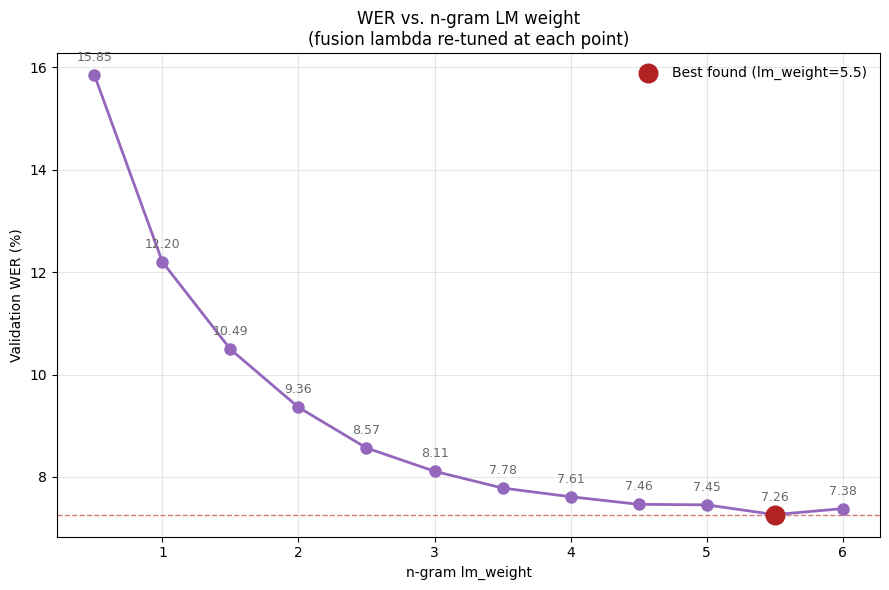

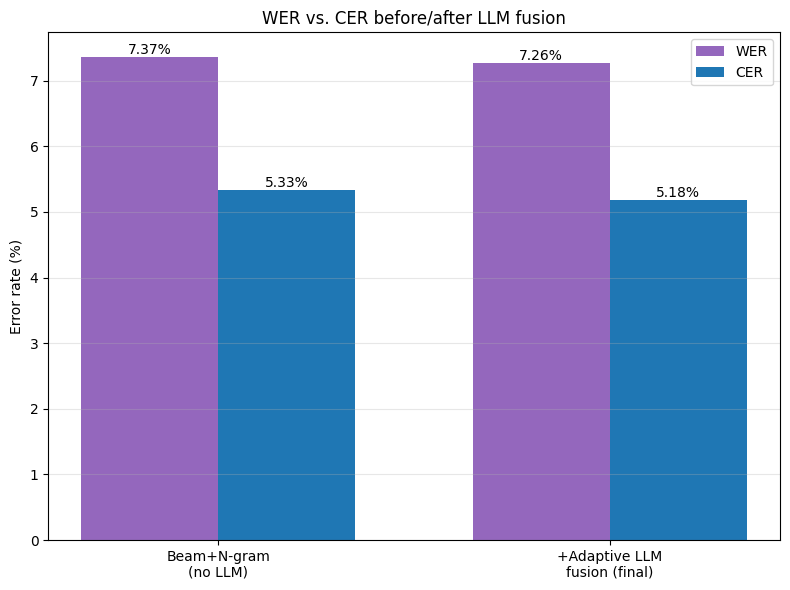

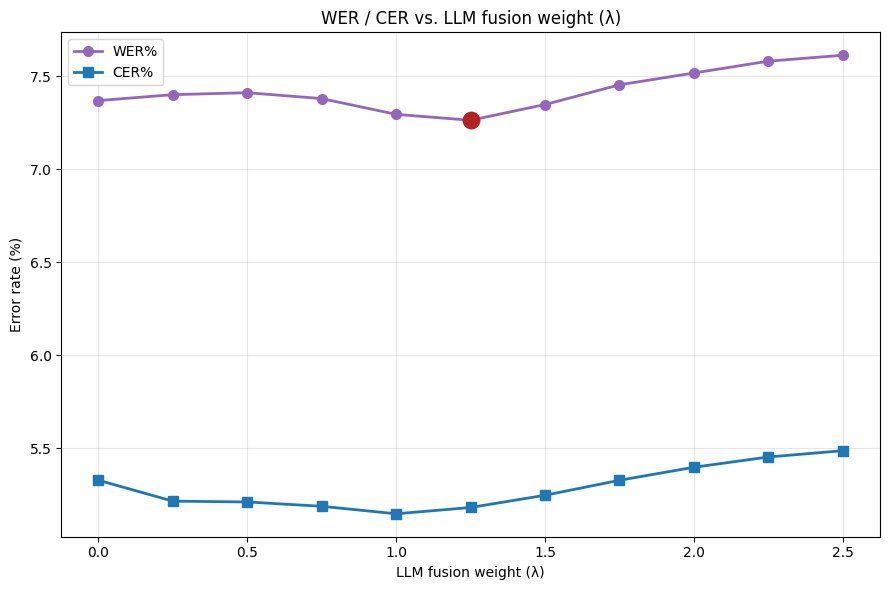


>>> Final: LM_WEIGHT=5.5, LLM_FUSION_WEIGHT=1.25 (WER=7.26%, CER=5.18%). `decoder` global is already rebuilt with this lm_weight.


In [ ]:
# ============================================================================
# BLOCK 5.6 · HYPERPARAMETER GRID SEARCH  (joint LM_WEIGHT x LAMBDA_GRID)
# ============================================================================
# For every lm_weight in LM_WEIGHT_GRID: rebuild the beam/n-gram decoder, get
# its n-best output + LLM scores ONCE, then cheaply evaluate every lambda in
# LAMBDA_GRID via fuse_pick (no LLM recompute needed per-lambda). This gives
# a true joint (lm_weight, lambda) grid without redoing the expensive decode
# or LLM-scoring pass for every lambda value.
#
# Produces the 3 summary plots at the end:
#   1) WER vs. n-gram LM weight (best lambda re-tuned at each lm_weight)
#   2) WER vs. CER before/after LLM fusion (bar chart)
#   3) WER / CER vs. LLM fusion weight (lambda), at the best lm_weight found
# ============================================================================
import itertools
import time

assert RUN_HYPERPARAM_SWEEPS, (
    "RUN_HYPERPARAM_SWEEPS is False (set in BLOCK 1 / CONFIG cell). "
    "This cell is the sweep itself, so flip RUN_HYPERPARAM_SWEEPS = True "
    "in BLOCK 1 and re-run from there before running this cell."
)

LM_WEIGHT_GRID = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
LAMBDA_GRID = np.round(np.arange(0.0, 2.5 + 1e-9, 0.25), 2).tolist()          # [0.0, 0.25, ..., 2.5]

assert 'val_emissions' in globals(), "Run BLOCK 5.4 first (need val_emissions/val_lengths/val_refs/val_days)."

print(f"LM_WEIGHT_GRID ({len(LM_WEIGHT_GRID)} values): {LM_WEIGHT_GRID}")
print(f"LAMBDA_GRID ({len(LAMBDA_GRID)} values): {LAMBDA_GRID}")


def decode_nbest_and_cache(dec, batch_size=16):
    """Full n-best decode + gate calibration + LLM-score caching for one decoder.
    Returns (decoder_results, hyps_cache, llm_scores_cache)."""
    decoder_results = []
    for i in range(0, len(val_emissions), batch_size):
        decoder_results.extend(dec(val_emissions[i:i + batch_size], val_lengths[i:i + batch_size]))
    calibrate_llm_gate_threshold(decoder_results)

    hyps_cache, llm_scores_cache = [], []
    for sample_result in decoder_results:
        if not sample_result:
            hyps_cache.append([""])
            llm_scores_cache.append(None)
            continue
        hyps = [" ".join(h.words) if h.words else "" for h in sample_result]
        hyps_cache.append(hyps)
        llm_scores_cache.append(
            None if (not any(hyps)) or _is_gated(sample_result)
            else compute_llm_scores(hyps, batch_size=len(hyps))
        )
    return decoder_results, hyps_cache, llm_scores_cache


def wer_cer_for_lambda(decoder_results, hyps_cache, llm_scores_cache, lam):
    preds, _ = _predict_adaptive(decoder_results, hyps_cache, llm_scores_cache, base_lambda=lam)
    pairs = [(r, h) for r, h in zip(val_refs, preds) if r and r.strip()]
    refs_c = [r for r, _ in pairs]
    hyps_c = [h if h.strip() else "<empty>" for _, h in pairs]
    return corpus_wer(refs_c, hyps_c), corpus_cer(refs_c, hyps_c)


# ---------------------------------------------------------------------------
# Joint grid search: one decode+LLM-cache pass per lm_weight, then a cheap
# lambda sweep on top of it.
# ---------------------------------------------------------------------------
print("\n=== Joint LM_WEIGHT x LAMBDA_GRID sweep ===")
grid_rows = []
best_by_lm_weight_cache = {}  # lm_weight -> (decoder_results, hyps_cache, llm_scores_cache)
t0 = time.time()
for lw in tqdm(LM_WEIGHT_GRID, desc="LM_WEIGHT outer loop"):
    dec_i = build_decoder(lm_weight=lw)
    decoder_results, hyps_cache, llm_scores_cache = decode_nbest_and_cache(dec_i, DECODE_BATCH)
    best_by_lm_weight_cache[lw] = (decoder_results, hyps_cache, llm_scores_cache)
    for lam in LAMBDA_GRID:
        wer_i, cer_i = wer_cer_for_lambda(decoder_results, hyps_cache, llm_scores_cache, lam)
        grid_rows.append({'lm_weight': lw, 'lambda': lam, 'wer': wer_i, 'cer': cer_i})
    del dec_i
print(f"Joint sweep took {time.time() - t0:.1f}s ({len(grid_rows)} (lm_weight, lambda) combos)")

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv(os.path.join(CONFIG['checkpoint_dir'], 'hparam_grid_full.csv'), index=False)

# Global best (lm_weight, lambda) combo.
best_row = grid_df.loc[grid_df['wer'].idxmin()]
BEST_LM_WEIGHT = float(best_row['lm_weight'])
BEST_LAMBDA = float(best_row['lambda'])
print(f"\nBest combo: lm_weight={BEST_LM_WEIGHT}, lambda={BEST_LAMBDA} "
      f"-> WER={best_row['wer'] * 100:.2f}%, CER={best_row['cer'] * 100:.2f}%")

# Per-lm_weight best (lambda re-tuned at each point) - for chart 1.
per_lmweight_best = grid_df.loc[grid_df.groupby('lm_weight')['wer'].idxmin()].sort_values('lm_weight')

# Lambda sweep AT the best lm_weight - for chart 3.
lambda_at_best = grid_df[grid_df['lm_weight'] == BEST_LM_WEIGHT].sort_values('lambda').reset_index(drop=True)

# Baseline (beam+n-gram only, i.e. lambda=0) at the best lm_weight - for chart 2.
baseline_row = lambda_at_best[lambda_at_best['lambda'] == 0.0].iloc[0]

LM_WEIGHT = BEST_LM_WEIGHT
LLM_FUSION_WEIGHT = BEST_LAMBDA
CONFIG['llm_fusion_weight'] = BEST_LAMBDA
decoder = build_decoder(lm_weight=LM_WEIGHT)  # leave the live decoder set to the winning combo

with open(os.path.join(CONFIG['checkpoint_dir'], 'best_hparams.json'), 'w') as f:
    json.dump({
        'best_lm_weight': BEST_LM_WEIGHT,
        'best_lambda': BEST_LAMBDA,
        'wer_beam_ngram_only': float(baseline_row['wer']),
        'cer_beam_ngram_only': float(baseline_row['cer']),
        'wer_full_pipeline': float(best_row['wer']),
        'cer_full_pipeline': float(best_row['cer']),
    }, f, indent=2)
print("Saved: hparam_grid_full.csv, best_hparams.json")

# ============================================================================
# PLOT 1 · WER vs. n-gram LM weight (fusion lambda re-tuned at each point)
# ============================================================================
fig1, ax1 = plt.subplots(figsize=(9, 6))
x1 = per_lmweight_best['lm_weight'].tolist()
y1 = (per_lmweight_best['wer'] * 100).tolist()
ax1.plot(x1, y1, color='tab:purple', marker='o', markersize=8, linewidth=2, zorder=3)
for x, y in zip(x1, y1):
    ax1.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='dimgray')
best_wer_pct = float(best_row['wer']) * 100
ax1.scatter([BEST_LM_WEIGHT], [best_wer_pct], color='firebrick', s=180, zorder=5,
            label=f'Best found (lm_weight={BEST_LM_WEIGHT:g})')
ax1.axhline(best_wer_pct, color='firebrick', linestyle='--', linewidth=1, alpha=0.6)
ax1.set_xlabel('n-gram lm_weight')
ax1.set_ylabel('Validation WER (%)')
ax1.set_title('WER vs. n-gram LM weight\n(fusion lambda re-tuned at each point)')
ax1.legend(loc='upper right', frameon=False)
ax1.grid(alpha=0.3)
fig1.tight_layout()
fig1.savefig(os.path.join(figures_dir, 'lmweight_sweep.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 2 · WER vs. CER before/after LLM fusion
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(8, 6))
categories = ['Beam+N-gram\n(no LLM)', '+Adaptive LLM\nfusion (final)']
wer_vals = [float(baseline_row['wer']) * 100, float(best_row['wer']) * 100]
cer_vals = [float(baseline_row['cer']) * 100, float(best_row['cer']) * 100]
bar_w = 0.35
xpos = np.arange(len(categories))
bars_wer = ax2.bar(xpos - bar_w / 2, wer_vals, bar_w, color='tab:purple', label='WER')
bars_cer = ax2.bar(xpos + bar_w / 2, cer_vals, bar_w, color='tab:blue', label='CER')
for bars in (bars_wer, bars_cer):
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.2f}%',
                 ha='center', va='bottom', fontsize=10)
ax2.set_xticks(xpos)
ax2.set_xticklabels(categories)
ax2.set_ylabel('Error rate (%)')
ax2.set_title('WER vs. CER before/after LLM fusion')
ax2.legend(frameon=True)
ax2.grid(alpha=0.3, axis='y')
fig2.tight_layout()
fig2.savefig(os.path.join(figures_dir, 'wer_cer_before_after.png'), dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 3 · WER / CER vs. LLM fusion weight (lambda), at the best lm_weight
# ============================================================================
fig3, ax3 = plt.subplots(figsize=(9, 6))
x3 = lambda_at_best['lambda'].tolist()
wer3 = (lambda_at_best['wer'] * 100).tolist()
cer3 = (lambda_at_best['cer'] * 100).tolist()
ax3.plot(x3, wer3, color='tab:purple', marker='o', markersize=7, linewidth=2, label='WER%')
ax3.plot(x3, cer3, color='tab:blue', marker='s', markersize=7, linewidth=2, label='CER%')
best_idx = int(np.argmin(wer3))
ax3.scatter([x3[best_idx]], [wer3[best_idx]], color='firebrick', s=140, zorder=5)
ax3.set_xlabel('LLM fusion weight (\u03bb)')
ax3.set_ylabel('Error rate (%)')
ax3.set_title('WER / CER vs. LLM fusion weight (\u03bb)')
ax3.legend(frameon=True)
ax3.grid(alpha=0.3)
fig3.tight_layout()
fig3.savefig(os.path.join(figures_dir, 'lambda_sweep.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n>>> Final: LM_WEIGHT={BEST_LM_WEIGHT}, LLM_FUSION_WEIGHT={BEST_LAMBDA} "
      f"(WER={best_row['wer'] * 100:.2f}%, CER={best_row['cer'] * 100:.2f}%). "
      f"`decoder` global is already rebuilt with this lm_weight.")


# BLOCK 6 · [OPTIONAL] GENERATE KAGGLE SUBMISSION FROM THE TEST SET


In [12]:
# ============================================================================
# BLOCK 6 · [OPTIONAL] GENERATE KAGGLE SUBMISSION FROM THE TEST SET
# ============================================================================
GENERATE_SUBMISSION = True   # set False to stop after validation


def block_load_test_data(data_dir, session2idx, feat_mean, feat_std, clip=5.0):
    files = sorted(glob(f'{data_dir}/**/data_test.hdf5', recursive=True))
    all_samples, sample_id = [], 0
    for filepath in tqdm(files, desc="Loading Test HDF5"):
        session = Path(filepath).parent.name
        with h5py.File(filepath, 'r') as f:
            trial_keys = [k for k in f.keys() if 'trial' in k.lower()]
            entries = []
            for trial_key in trial_keys:
                trial = f[trial_key]
                if 'input_features' not in trial:
                    continue
                entries.append((int(trial.attrs.get('block_num', 0)),
                                int(trial.attrs.get('trial_num', 0)), trial_key))
            entries.sort(key=lambda e: (e[0], e[1]))
            for block_num, trial_num, trial_key in entries:
                trial = f[trial_key]
                features = trial['input_features'][:trial.attrs['n_time_steps']]
                features = torch.FloatTensor(features)
                features = (features - feat_mean) / feat_std
                features = torch.clamp(features, -clip, clip)
                all_samples.append({
                    'id': sample_id, 'session': session, 'day_idx': session2idx[session],
                    'block_num': block_num, 'trial_num': trial_num,
                    'trial_key': trial_key, 'features': features,
                })
                sample_id += 1
    return all_samples


def extract_emissions(model, samples, device):
    model.eval()
    all_emissions, all_lengths, all_ids = [], [], []
    with torch.no_grad():
        for i in tqdm(range(0, len(samples), 32), desc='Extracting Test Emissions'):
            batch = samples[i:i + 32]
            features = [s['features'] for s in batch]
            lengths = torch.LongTensor([len(f) for f in features])
            day_idx = torch.LongTensor([s['day_idx'] for s in batch]).to(device)
            features_padded = torch.nn.utils.rnn.pad_sequence(features, batch_first=True).to(device)
            sorted_lengths, sorted_idx = lengths.sort(descending=True)
            with amp_autocast(enabled=CONFIG['use_amp']):
                log_probs, output_lengths = model(
                    features_padded[sorted_idx], sorted_lengths, day_idx[sorted_idx])
            log_probs = log_probs.transpose(0, 1).float().cpu()

            unsorted = torch.empty_like(log_probs)
            unsorted_lengths = torch.empty_like(output_lengths.cpu())
            unsorted[sorted_idx] = log_probs
            unsorted_lengths[sorted_idx] = output_lengths.cpu()
            all_emissions.append(unsorted)
            all_lengths.append(unsorted_lengths)
            all_ids.extend([s['id'] for s in batch])

    max_T = max(e.shape[1] for e in all_emissions)
    all_emissions = [F.pad(e, (0, 0, 0, max_T - e.shape[1])) for e in all_emissions]
    return torch.cat(all_emissions, dim=0), torch.cat(all_lengths, dim=0), all_ids


if GENERATE_SUBMISSION:
    print("\nLoading test set...")
    test_samples = block_load_test_data(CONFIG['data_dir'], session2idx, feat_mean, feat_std)
    print(f"Test samples: {len(test_samples)}")

    test_emissions, test_lengths, test_ids = extract_emissions(model, test_samples, CONFIG['device'])

    print("Running batched beam search on test set...")
    test_decoder_results = []
    for i in tqdm(range(0, len(test_emissions), DECODE_BATCH), desc="Beam search"):
        test_decoder_results.extend(decoder(test_emissions[i:i + DECODE_BATCH],
                                             test_lengths[i:i + DECODE_BATCH]))

    # Reuse the validation-calibrated gate thresholds; fall back only if missing.
    if LLM_GATE_THRESHOLD is None or LLM_GATE_MARGIN_THRESHOLD is None:
        print("WARNING: no validation-calibrated gate thresholds - calibrating on test scores.")
        calibrate_llm_gate_threshold(test_decoder_results)

    print(f"Score-fusion LLM rescoring with LLM_FUSION_WEIGHT={LLM_FUSION_WEIGHT}...")
    FINAL_PREDICTIONS = []
    n_gated_low_score, n_gated_confident = 0, 0
    for sample_result in tqdm(test_decoder_results, desc="Gated LLM rescoring"):
        if sample_result:
            if normalized_ngram_score(sample_result[0]) < LLM_GATE_THRESHOLD:
                n_gated_low_score += 1
            elif top1_margin(sample_result) > LLM_GATE_MARGIN_THRESHOLD:
                n_gated_confident += 1
        FINAL_PREDICTIONS.append(gated_rescore(sample_result))

    n_gated_total = n_gated_low_score + n_gated_confident
    print(f"Skipped LLM on {n_gated_total}/{len(test_decoder_results)} "
          f"({100 * n_gated_total / max(len(test_decoder_results), 1):.1f}%): "
          f"{n_gated_low_score} low-score, {n_gated_confident} high-confidence.")

    # Match whatever columns sample_submission.csv expects.
    sample_sub_path = None
    for pattern in [os.path.join(os.path.dirname(CONFIG['data_dir']), '**', 'sample_submission.csv'),
                    '/kaggle/input/**/sample_submission.csv']:
        matches = glob(pattern, recursive=True)
        if matches:
            sample_sub_path = matches[0]
            break

    if sample_sub_path:
        sample_df = pd.read_csv(sample_sub_path)
        id_col, text_col = sample_df.columns[0], sample_df.columns[1]
        print(f"Using columns '{id_col}', '{text_col}' from {sample_sub_path}")
    else:
        id_col, text_col = 'id', 'text'
        print("No sample_submission.csv found - defaulting to 'id','text'.")

    df = pd.DataFrame({id_col: test_ids, text_col: FINAL_PREDICTIONS})
    df = df.sort_values(id_col).reset_index(drop=True)
    df[id_col] = range(len(df))
    df.to_csv('submission.csv', index=False)
    print('\nFinished! Predictions written to submission.csv')
    print(df.head(10).to_string(index=False))


Loading test set...


Loading Test HDF5: 100%|██████████| 41/41 [00:51<00:00,  1.27s/it]


Test samples: 1450


Extracting Test Emissions: 100%|██████████| 46/46 [00:26<00:00,  1.73it/s]


Running batched beam search on test set...


Beam search: 100%|██████████| 91/91 [02:03<00:00,  1.35s/it]


Score-fusion LLM rescoring with LLM_FUSION_WEIGHT=1.25...


Gated LLM rescoring: 100%|██████████| 1450/1450 [35:08<00:00,  1.45s/it]


Skipped LLM on 294/1450 (20.3%): 15 low-score, 279 high-confidence.
No sample_submission.csv found - defaulting to 'id','text'.

Finished! Predictions written to submission.csv
 id                                        text
  0 i get tired with the song and dance routine
  1                                  every here
  2                  you weren't a big surprise
  3                i think maybe you look at it
  4            show that they too have problems
  5                            i enjoy that too
  6                      i moved to kansas city
  7                     maybe four times a week
  8           when he sees it to his opponent's
  9                  there's just no one around
